In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Temperature Analysis

Generate hourly temperature data for one week using NumPy.

In [2]:
temp = {}
days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
for day in days:
    one = np.random.randint(30,35,8)
    two = np.random.randint(35,40,8)
    three = np.random.randint(30,35,8)

    temp[day] = np.concatenate([np.random.randint(30,33,6), np.random.randint(33,35,3), np.random.randint(35,37,3),
                                np.random.randint(37,40,3), np.random.randint(36,39,3), np.random.randint(33,35,3),
                                np.random.randint(30,33,3)])

In [3]:
temp

{'Mon': array([31, 31, 30, 32, 31, 31, 33, 33, 34, 36, 35, 36, 39, 38, 37, 37, 37,
        36, 34, 34, 34, 30, 30, 31]),
 'Tue': array([30, 32, 30, 32, 30, 30, 34, 33, 33, 35, 35, 35, 37, 39, 37, 38, 37,
        38, 33, 34, 33, 32, 31, 31]),
 'Wed': array([32, 31, 30, 31, 30, 30, 33, 33, 33, 35, 35, 36, 37, 39, 38, 38, 37,
        36, 33, 33, 34, 30, 30, 31]),
 'Thu': array([30, 30, 30, 31, 30, 30, 34, 34, 34, 36, 35, 35, 39, 38, 39, 36, 37,
        38, 34, 34, 33, 31, 32, 32]),
 'Fri': array([31, 32, 31, 30, 32, 32, 33, 33, 33, 35, 36, 36, 39, 37, 39, 37, 36,
        37, 33, 34, 33, 32, 31, 30]),
 'Sat': array([30, 30, 31, 30, 30, 30, 34, 34, 33, 35, 36, 35, 39, 37, 38, 36, 37,
        38, 34, 34, 34, 32, 30, 30]),
 'Sun': array([32, 32, 31, 32, 31, 31, 33, 33, 33, 35, 36, 35, 39, 38, 37, 37, 38,
        37, 33, 33, 33, 32, 31, 32])}

Store it in a Pandas DataFrame with datetime index.

In [43]:
temp_df = pd.DataFrame(temp, index=[f"{h}:00" for h in range(24)])
temp_df.head()

,Mon,Tue,Wed,Thu,Fri,Sat,Sun
0:00,31,30,32,30,31,30,32
1:00,31,32,31,30,32,30,32
2:00,30,30,30,30,31,31,31
3:00,32,32,31,31,30,30,32
4:00,31,30,30,30,32,30,31


In [5]:
temp_df['Avg_temp'] = temp_df.mean(axis=1)

In [44]:
temp_df.head()

,Mon,Tue,Wed,Thu,Fri,Sat,Sun
0:00,31,30,32,30,31,30,32
1:00,31,32,31,30,32,30,32
2:00,30,30,30,30,31,31,31
3:00,32,32,31,31,30,30,32
4:00,31,30,30,30,32,30,31


Plot the temperature trend over the week using a line chart.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


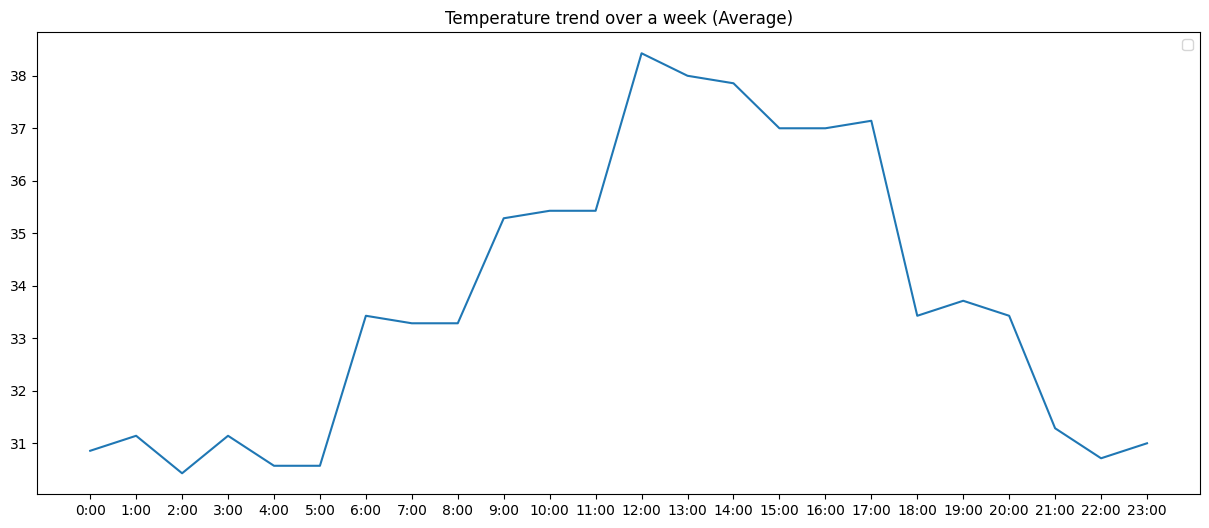

In [7]:
plt.figure(figsize=(15,6))
plt.plot(temp_df['Avg_temp'])
plt.legend()
plt.title("Temperature trend over a week (Average)")
plt.show()

### Random Sales Dataset

Simulate sales data for 5 products over 30 days:
 - Columns: "date", "product", "units_sold", "unit_price".


In [8]:
date =  np.datetime64('2025-01-01')
dates = [date + i for i in range(30)]

In [9]:
sales_data = {
    "date" : dates,
    "product" : np.arange(1,31),
    "units_sold" : np.random.randint(0,20,30),
    "unit_price" : np.random.randint(30,100,30)
}

In [10]:
sales_df = pd.DataFrame(sales_data, index=[n for n in range(1,31)])

Compute total revenue per product.

In [11]:
sales_df['revenue'] = sales_df['unit_price']*sales_df['units_sold']
sales_df.head()

,date,product,units_sold,unit_price,revenue
1,2025-01-01,1,0,90,0
2,2025-01-02,2,15,96,1440
3,2025-01-03,3,18,33,594
4,2025-01-04,4,7,90,630
5,2025-01-05,5,8,87,696


Plot a bar chart of revenue by product.

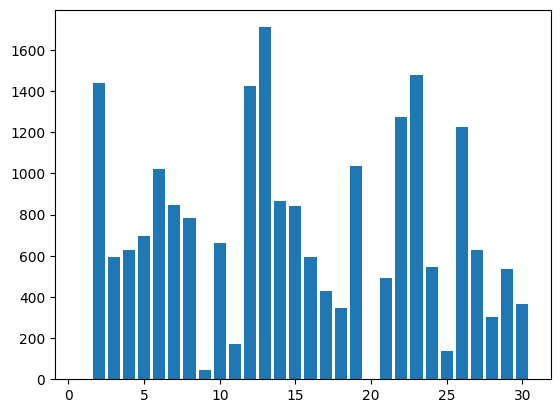

In [12]:
plt.bar(sales_df['product'], sales_df['revenue'])
plt.show()

### Missing Data Handling

Create a DataFrame with some missing values:

In [13]:
numerical_data = np.random.randint(1,10,10).astype('float')
numerical_data[[2,5,7]] = np.nan

In [14]:
data = {
    "numerical" : numerical_data,
    "categorical": np.random.choice([np.nan, "a", "b", "c", "d"], size=10),
    }

In [15]:
data_df = pd.DataFrame(data)
data_df

,numerical,categorical
0,5.0,nan
1,3.0,d
2,NaN,d
3,8.0,b
4,7.0,c
5,NaN,c
6,2.0,nan
7,NaN,nan
8,9.0,b
9,2.0,a


In [16]:
data_bofore = data_df.copy()

- Fill missing numeric values with the mean.
- Fill missing categorical values with mode.


In [17]:
data_df['categorical'] = data_df['categorical'].replace('nan', np.nan)
data_df['numerical'] = data_df['numerical'].fillna(data_df['numerical'].mean())
data_df['categorical'] = data_df['categorical'].fillna(data_df['categorical'].mode()[0])
data_df


,numerical,categorical
0,5.000000,b
1,3.000000,d
2,5.142857,d
3,8.000000,b
4,7.000000,c
5,5.142857,c
6,2.000000,b
7,5.142857,b
8,9.000000,b
9,2.000000,a


Plot before vs after comparison using boxplots.


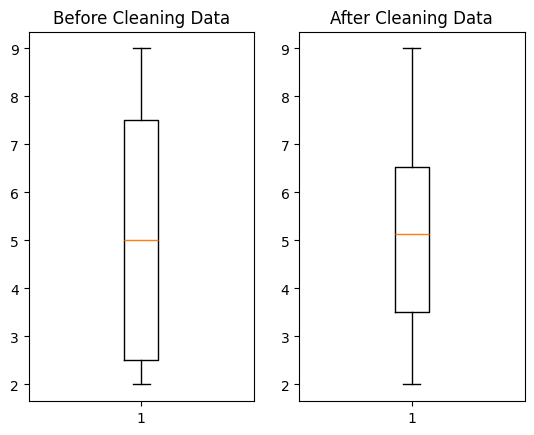

In [18]:
plt.subplot(1,2,1)
plt.boxplot(data_bofore['numerical'].dropna())
plt.title("Before Cleaning Data")

plt.subplot(1,2,2)
plt.boxplot(data_df['numerical'])
plt.title("After Cleaning Data")
plt.show()

### Customer Segregation

Simulate a customer dataset with features like "age", "income", "spending_score".

In [19]:
customer_data = {
    "age" : np.random.randint(18,50,100),
    "income" : np.random.randint(3000000, 12000000,100),
    "spending_score" : np.random.randint(1,101,100)
}
customer_df = pd.DataFrame(customer_data)
customer_df.head()

,age,income,spending_score
0,20,11327119,65
1,40,9383294,49
2,24,8623338,28
3,31,3128016,24
4,38,6370767,9


Use quantile-based binning to categorize customers into Low, Medium, High spenders.

In [20]:
conditions = [customer_df['spending_score']  <= 30, 
              (customer_df['spending_score'] > 30) & (customer_df['spending_score'] < 70),
              customer_df['spending_score'] >= 70]
category = ['Low','Medium', 'High']

customer_df['type_of_spendor'] = np.select(conditions,category)
customer_df

,age,income,spending_score,type_of_spendor
0,20,11327119,65,Medium
1,40,9383294,49,Medium
2,24,8623338,28,Low
3,31,3128016,24,Low
4,38,6370767,9,Low
...,...,...,...,...
95,41,4067034,51,Medium
96,36,8113178,55,Medium
97,49,5445099,61,Medium
98,35,4697820,91,High


Visualize age vs income, colored by spending category (scatter plot)

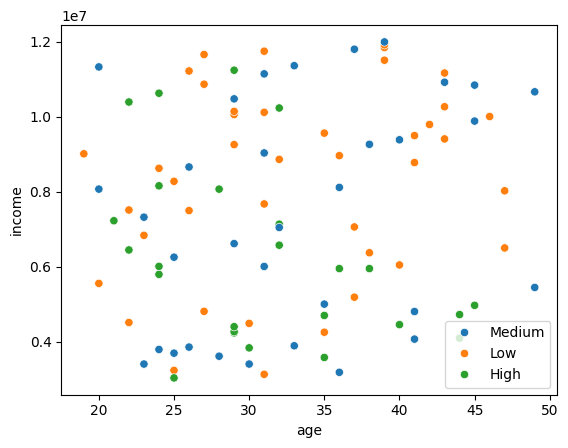

In [21]:
sns.scatterplot(x='age', y ='income',data=customer_df, hue='type_of_spendor')
plt.legend(loc=0)
plt.show()

### Time Series Resampling

Generate minute-level stock price data for a day.

In [22]:
prices =  np.random.rand(60*24)
minutes = np.arange(60*24)

time = pd.to_timedelta(minutes, unit='m').astype(str)
time = [time.split()[-1] for time in time]

stock_minute ={"prices": prices,
               "time" : time
               }
stock_minute_df = pd.DataFrame(stock_minute, index=time)
stock_minute_df.head()

,prices,time
00:00:00,0.720386,00:00:00
00:01:00,0.798293,00:01:00
00:02:00,0.798213,00:02:00
00:03:00,0.450497,00:03:00
00:04:00,0.033151,00:04:00


Resample it to hourly average prices using Pandas.

In [23]:
stock_minute_df['hour'] = stock_minute_df['time'].str.slice(0,2)
stock_hour_df = stock_minute_df.groupby("hour",as_index=False)['prices'].mean()
stock_hour_df.head()

,hour,prices
0,00,0.503265
1,01,0.573420
2,02,0.444947
3,03,0.472973
4,04,0.475812


Plot both the original and resampled series.

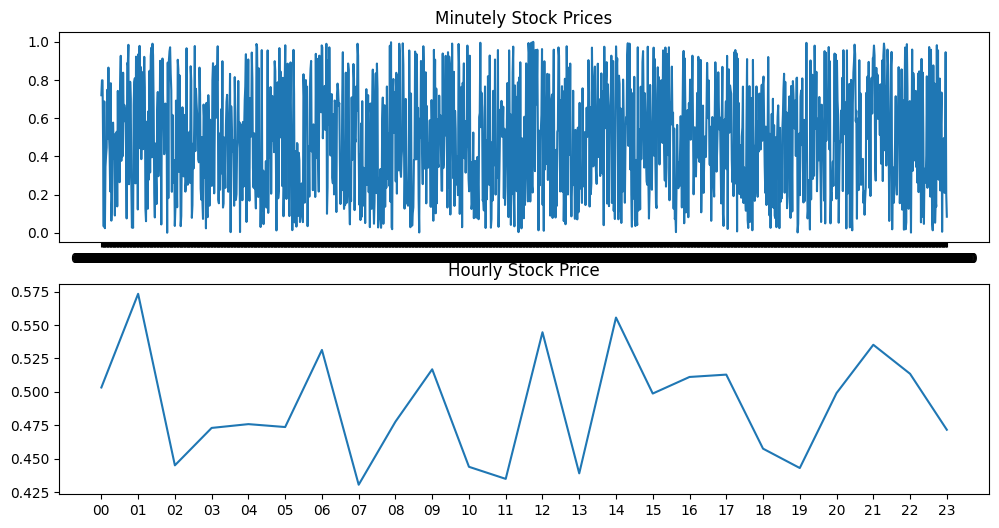

In [24]:
fig,axs = plt.subplots(nrows = 2, ncols = 1, figsize=(12,6))

axs[0].plot(stock_minute_df['time'],stock_minute_df['prices'])
axs[0].set_title("Minutely Stock Prices")

axs[1].plot(stock_hour_df['hour'],stock_hour_df['prices'])
axs[1].set_title("Hourly Stock Price")
plt.show()


### Outlier Detection

Create a dataset of test scores with intentional outliers.

In [25]:
scores = np.random.randint(60,90,100)
scores[[3,67,90]] = 20
scores[[7,23]] = 10
scores[[10,48,66]] = 110

scores

array([ 64,  88,  83,  20,  73,  62,  76,  10,  80,  84, 110,  78,  68,
        67,  66,  74,  79,  76,  60,  69,  71,  86,  72,  10,  60,  64,
        77,  89,  80,  63,  68,  69,  65,  69,  71,  71,  61,  68,  87,
        82,  76,  74,  67,  62,  70,  88,  68,  61, 110,  60,  60,  84,
        73,  74,  69,  73,  69,  84,  72,  88,  80,  67,  64,  64,  70,
        69, 110,  20,  85,  71,  75,  82,  82,  69,  73,  66,  89,  66,
        64,  84,  67,  78,  85,  81,  75,  66,  76,  80,  80,  69,  20,
        83,  60,  89,  71,  73,  86,  70,  81,  63])

In [26]:
scores_df = pd.DataFrame(scores)
scores_df_with_outliers = scores_df.copy()

Detect outliers using IQR method.

In [27]:
median = scores_df.quantile(0.5)
quantiles = scores_df.quantile([0.25,0.75])
q1 = quantiles[0][0.25]
q3 = quantiles[0][0.75]
iqr = q3 - q1
lower_fence = q1 - 1.5*iqr
upper_fence = q3 + 1.5*iqr


Remove them and plot before/after distributions side-by-side.

In [28]:
scores_df_without_outliers = scores_df[(scores_df[0]>lower_fence) & (scores_df[0]<upper_fence)]

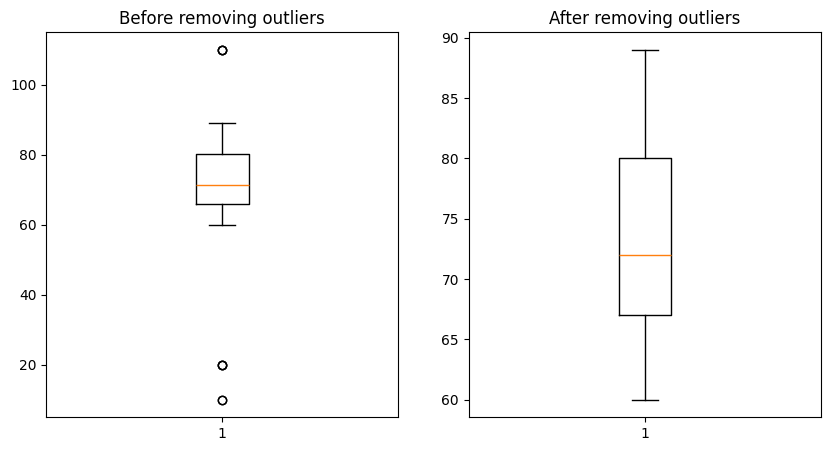

In [29]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.boxplot(scores_df_with_outliers)
plt.title("Before removing outliers")

plt.subplot(1,2,2)
plt.boxplot(scores_df_without_outliers)
plt.title("After removing outliers")
plt.show()

### Correlation Matrix

Simulate a dataset with multiple continuous variables.

In [30]:
customer_df

,age,income,spending_score,type_of_spendor
0,20,11327119,65,Medium
1,40,9383294,49,Medium
2,24,8623338,28,Low
3,31,3128016,24,Low
4,38,6370767,9,Low
...,...,...,...,...
95,41,4067034,51,Medium
96,36,8113178,55,Medium
97,49,5445099,61,Medium
98,35,4697820,91,High


In [31]:
customer_df.sort_values('age',inplace=True)
customer_df.drop('type_of_spendor',axis=1, inplace=True)

Compute the correlation matrix.

In [32]:
customer_df_corr = customer_df.corr()
customer_df_corr

,age,income,spending_score
age,1.000000,0.137756,-0.143510
income,0.137756,1.000000,-0.224089
spending_score,-0.143510,-0.224089,1.000000


Plot a heatmap of correlations using Seaborn.

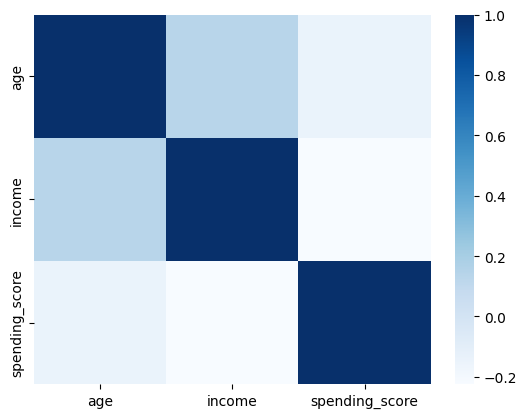

In [33]:
sns.heatmap(customer_df_corr, cmap='Blues')
plt.show()

### Multi-Index DataFrame

Simulate sales data with multi-level index (store, date).


In [34]:
stores = [1,2,3,4,5]
start_date =  np.datetime64('2025-01-01')
dates = [start_date + i for i in range(30)]

multi_index = pd.MultiIndex.from_product([stores,dates], names=['store','date'])
product = np.random.choice(['a','b','c','d','e'], size=len(multi_index))
unit_price_map = {'a': 10, 'b': 15, 'c': 12, 'd': 8, 'e': 20}

store_data = {
    "products" : product,
    "units_sold" : np.random.randint(1,10,len(multi_index))
}

store_data_df = pd.DataFrame(store_data, index=multi_index)
store_data_df['unit_price'] = store_data_df['products'].map(unit_price_map)
store_data_df['revenue'] = store_data_df['unit_price']*store_data_df['units_sold']


In [35]:
store_data_df

products  units_sold  unit_price  revenue
store date                                                
1     2025-01-01        d           7           8       56
      2025-01-02        c           4          12       48
      2025-01-03        e           1          20       20
      2025-01-04        b           6          15       90
      2025-01-05        c           1          12       12
...                   ...         ...         ...      ...
5     2025-01-26        e           2          20       40
      2025-01-27        a           9          10       90
      2025-01-28        a           1          10       10
      2025-01-29        c           3          12       36
      2025-01-30        e           9          20      180

[150 rows x 4 columns]

Compute total and average sales per store.

In [36]:
store_total = store_data_df.groupby('store').sum()
store_total

,products,units_sold,unit_price,revenue
store,,,,
1,dcebcaeadcdabdbaeaeeedbdadeeed,144,400,1868
2,dadcabcadeceaaeeddcecbdabcedec,149,385,1894
3,cbebbdeceeeacbbedcaaecebabddcc,159,421,2249
4,bddeadabcbedadaadbbcebeadeccdc,163,374,2033
5,dadedabebaebedceebedaddddeaace,159,396,2050


In [37]:
store_mean = store_data_df.groupby('store').mean(numeric_only=True)
store_mean

,units_sold,unit_price,revenue
store,,,
1,4.800000,13.333333,62.266667
2,4.966667,12.833333,63.133333
3,5.300000,14.033333,74.966667
4,5.433333,12.466667,67.766667
5,5.300000,13.200000,68.333333


Visualize store-wise sales using stacked bar chart.

In [38]:
revenue_by_store = store_data_df.groupby(['store','products'])['revenue'].sum().unstack(fill_value=0)
revenue_by_store

products,a,b,c,d,e
store,,,,,
1,270,450,132,336,680
2,410,180,276,288,740
3,210,495,420,184,940
4,250,555,288,400,540
5,280,390,72,448,860


Text(0.5, 1.0, 'Store Revenue Data by product')

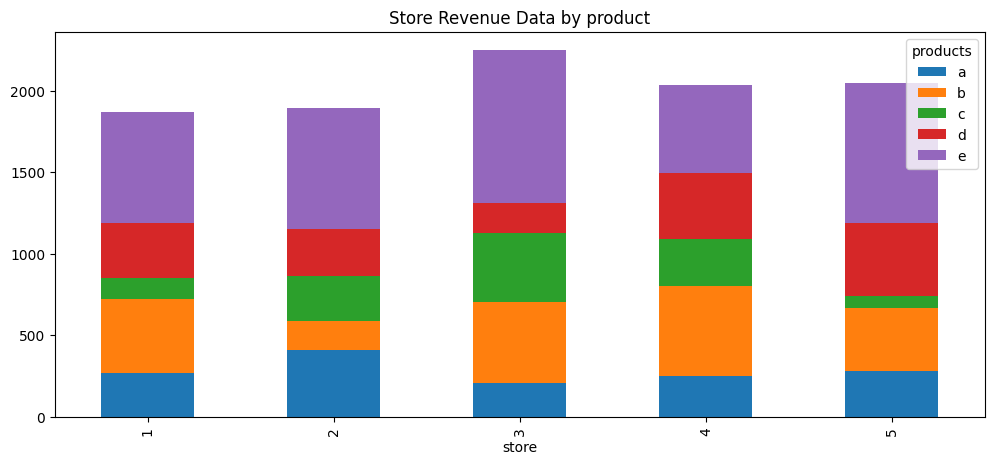

In [39]:
revenue_by_store.plot(kind='bar', stacked=True, figsize=(12,5))
plt.title("Store Revenue Data by product")

### Crosstab Analysis

Create a dataset of customer purchases:
- Columns: "gender", "age_group", "product_category", "purchase_amount".


In [40]:
customer_purchase = {
    "gender" : np.random.choice(["Male","Female"], size=100),
    "age_group" : np.random.choice(['<18','18-25','25-35','35-45','>45'],size=100),
    "product_category" : np.random.choice(["Electronics", "Food", "Medical", "Clothes", "Shoes", "Others"], size=100),
    "purchase_amount" : np.random.randint(100,500,100)
}
index = np.arange(1, 101)
customer_purchase_df = pd.DataFrame(customer_purchase,index=index)
customer_purchase_df

,gender,age_group,product_category,purchase_amount
1,Male,35-45,Food,469
2,Female,>45,Others,410
3,Female,<18,Medical,211
4,Male,>45,Shoes,483
5,Male,35-45,Medical,282
...,...,...,...,...
96,Female,25-35,Electronics,350
97,Female,25-35,Food,398
98,Female,35-45,Food,273
99,Male,>45,Electronics,482


Generate a crosstab of gender vs product category.

In [41]:
crosstab = pd.crosstab(customer_purchase_df['gender'], customer_purchase_df['product_category'])
crosstab

product_category,Clothes,Electronics,Food,Medical,Others,Shoes
gender,,,,,,
Female,11,11,7,10,6,8
Male,10,6,4,11,7,9


Visualize with a grouped bar chart.

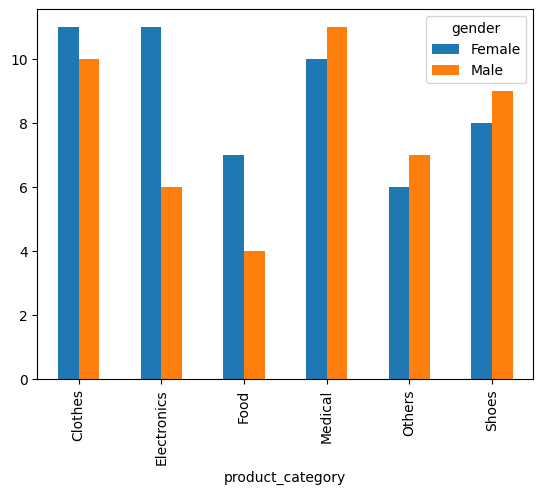

In [42]:
crosstab.T.plot(kind='bar')
plt.show()